Zomato data analysis project

step-1 importing libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv('Zomatodata.csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [8]:
df.isnull()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
143,False,False,False,False,False,False,False
144,False,False,False,False,False,False,False
145,False,False,False,False,False,False,False
146,False,False,False,False,False,False,False


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


 Convert the data type of column - rate

def handlerate(value):
    v=str(value).split('/')
    d=v[0]
    return float(d)
df['rate']=df['rate'].apply(handlerate)

    

In [16]:

df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


QUES-1. What type of restaurant do the majority of customers order from?

C:\Users\mansi\AppData\Local\Temp\ipykernel_20116\4041535259.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['listed_in(type)'],palette='rainbow')


<Axes: xlabel='listed_in(type)', ylabel='count'>

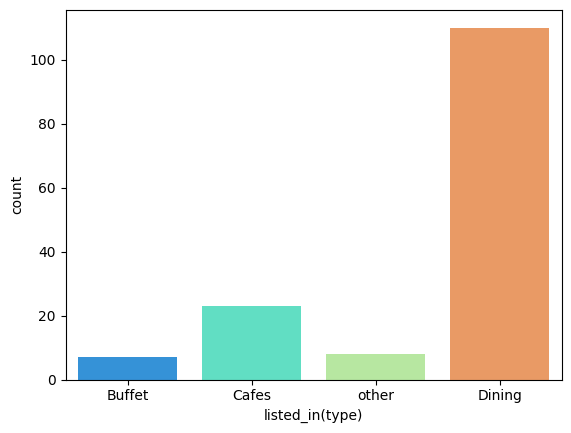

In [19]:
sns.countplot(x=df['listed_in(type)'],palette='rainbow')

QUES-2. How many votes has each type of restaurant recieved from customers?

In [25]:
grouped_data=df.groupby("listed_in(type)")['votes'].sum()
grouped_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

Text(0, 0.5, 'Votes')

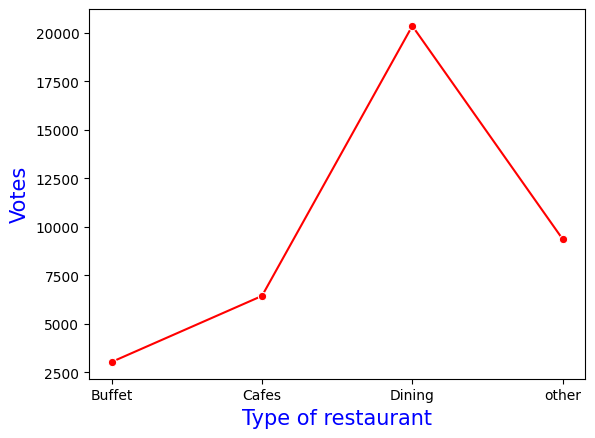

In [48]:
sns.lineplot(x=grouped_data.index,y=grouped_data.values,marker='o',color='red')
plt.xlabel("Type of restaurant",size=15,color='blue')
plt.ylabel('Votes',size=15,color='blue')

QUES-3. What are the ratings that the majority of restaurants have recieved?

<Axes: xlabel='rate', ylabel='Count'>

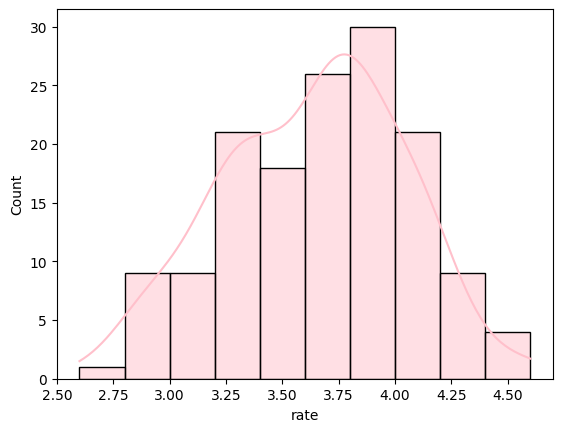

In [55]:
sns.histplot(df['rate'],bins=10,kde=True, color='pink')

QUES-4. Zomato has observed that most couples order most of their foods online.what is the average spending on each order?

C:\Users\mansi\AppData\Local\Temp\ipykernel_20116\3401172968.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['approx_cost(for two people)'],palette='rainbow')


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

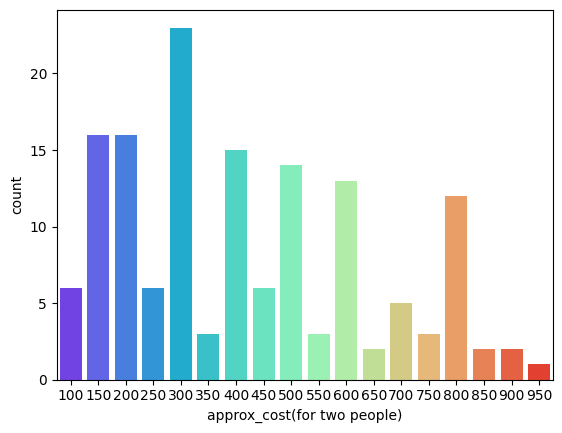

In [59]:
sns.countplot(x=df['approx_cost(for two people)'],palette='rainbow')

QUES-5. Which mode(online or offline) has recieved the maximum rating?

<Axes: xlabel='online_order', ylabel='rate'>

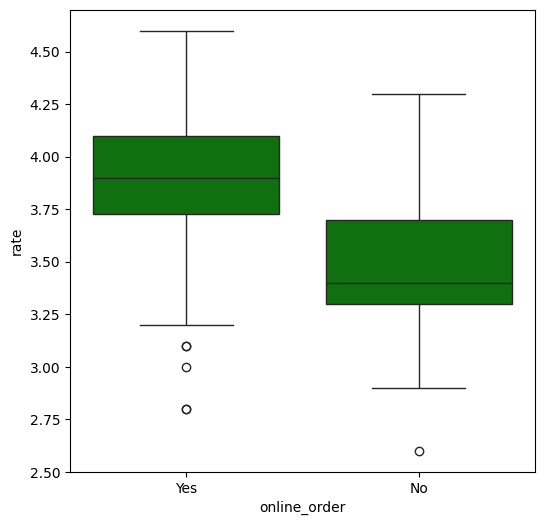

In [73]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=df,color='green')


QUES-6. Which type of restaurant recieved more offline orders,so that Zomato can prefer customers with some good offers?

In [75]:
pivot_table=df.pivot_table(index="listed_in(type)",columns='online_order',aggfunc='size',fill_value=0)
pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


<Axes: xlabel='online_order', ylabel='listed_in(type)'>

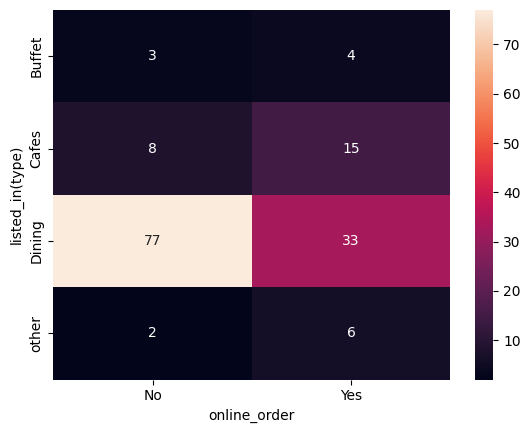

In [76]:
sns.heatmap(pivot_table,annot=True)